In [2]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

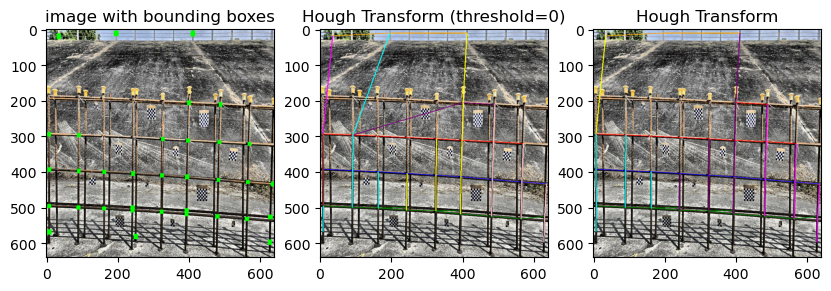

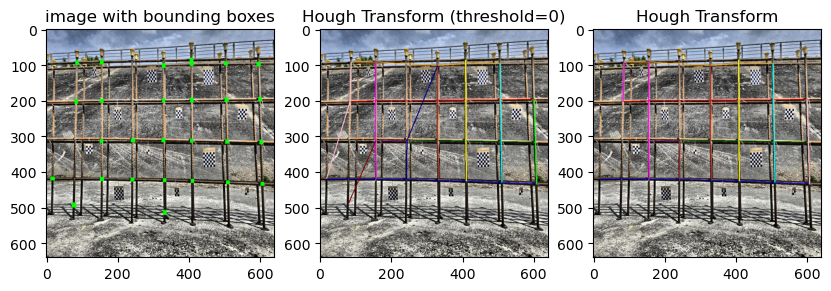

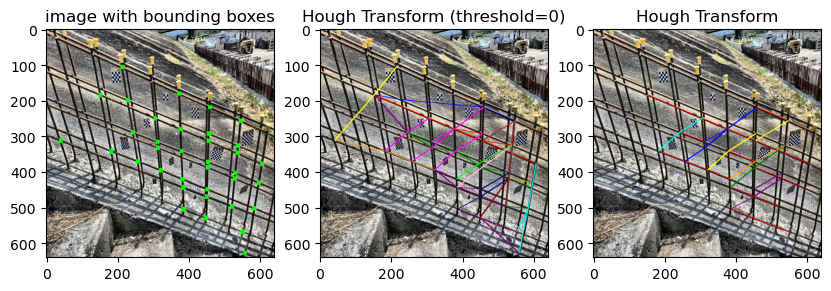

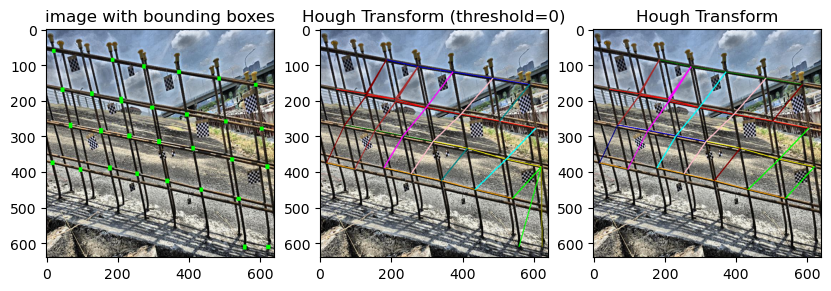

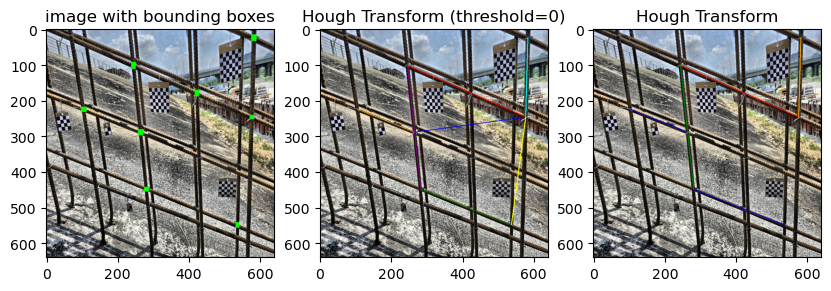

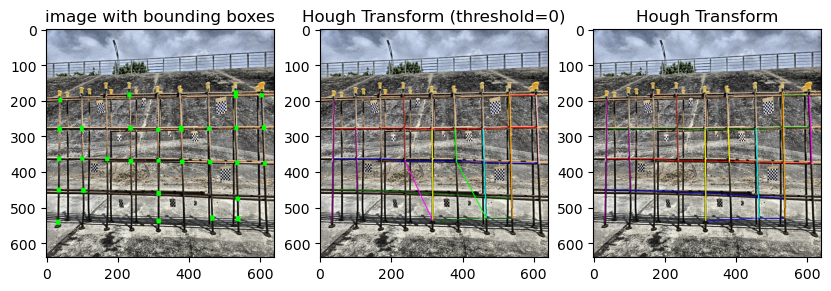

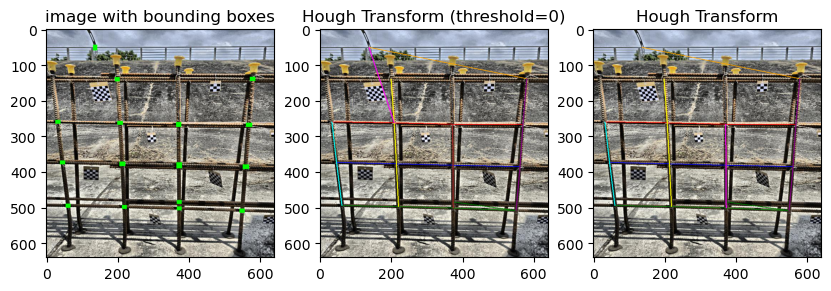

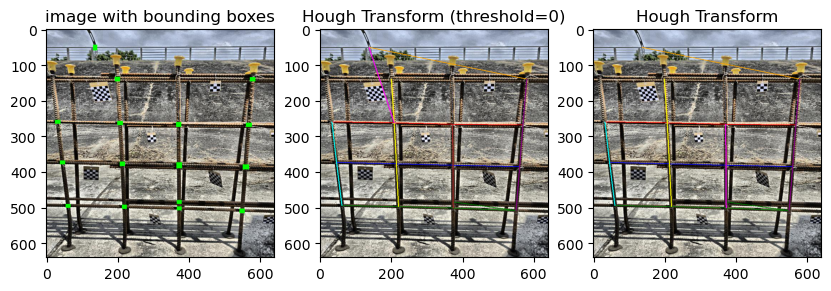

In [18]:
image_paths = [
    "data/intersect-detect-v2/test/images/20250624_101514_jpg.rf.71a3628766d6c3eca23e49e4c3292ab8.jpg",
    "data/intersect-detect-v2/test/images/20250624_101519_jpg.rf.edb4ed632e807f5282455bc59dcd0b0e.jpg",
    "data/intersect-detect-v2/test/images/20250624_102245_jpg.rf.139a5980debeff286a87a0bcdc2c754d.jpg",
    "data/intersect-detect-v2/test/images/20250624_103737_jpg.rf.51e5e2e127bfb3c6ec7510d8c6f183cf.jpg",
    "data/intersect-detect-v2/test/images/20250624_103836_jpg.rf.deb41f425f07a7abf03ef353d8f49d1e.jpg",
    "data/intersect-detect-v2/test/images/20250624_105630_jpg.rf.8f70fbabdf0547fad9b0754573352a16.jpg",
    "data/intersect-detect-v2/test/images/20250624_105725_jpg.rf.8fc32ef27d312eaf195a561cb49604b7.jpg",
    "data/intersect-detect-v2/test/images/20250624_105725.rf.8692fffaa0ab3c0a3064d2a9ef61c5ff.jpg",
]
model_path = "runs/detect-yolo12/train/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=10)

    return image


# Define different colors for different groups
colors = [
    "red", "blue", "green", "orange", "purple", "yellow", "cyan", "magenta", 
    "brown", "pink", "lime", "navy", "maroon", "olive", "teal", "silver",
    "gold", "indigo", "coral", "salmon", "khaki", "violet", "crimson", 
    "turquoise", "plum", "chocolate", "tomato", "orchid", "steelblue", 
    "darkgreen", "firebrick", "mediumblue", "darkorange", "darkviolet",
    "forestgreen", "hotpink", "royalblue", "darkred", "limegreen", "deeppink"
]

# Draw lines
def draw_lines(image_path, model_path, threshold=10):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    
    # Use different colors for different groups, cycling through the color list
    for i, shape in enumerate(data["shapes"]):
        lines = shape["lines"]
        color = colors[i % len(colors)]
        
        # Draw each line in the group
        for line in lines:
            draw_lines.line([tuple(line[0]), tuple(line[1])], fill=color, width=3)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("Hough Transform (threshold=0)")
    # Still applying line pruning
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("Hough Transform")
    plt.imshow(draw_lines(image_path, model_path))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
